# Playwright Basics

- it has a sync and also async api
- will paste a basic script below to show basics of this library

In [ ]:
from playwright.sync_api import sync_playwright


with sync_playwright() as playwright:
    # Launch a browser
    browser = playwright.chromium.launch(headless=False, slow_mo=500)
    # Create a new page
    page = browser.new_page()
    # Visit the playwright website
    page.goto("https://playwright.dev/python")

    # Locate a link element with "Docs" text
    docs_button = page.get_by_role("link", name="Docs")
    docs_button.click()

    # Get the url
    print("Docs:", page.url)

    browser.close()

- use the python repl to go step by step, really cool experience

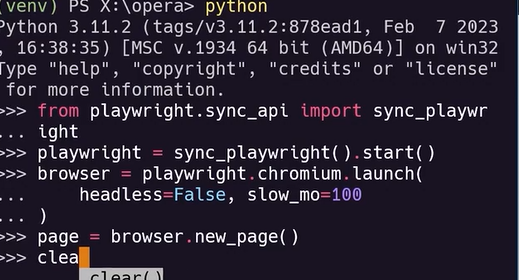

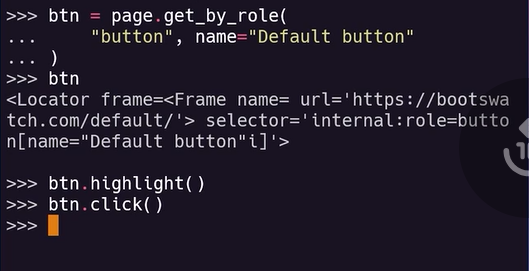

### get by something locator
---
- get_by_label
- get_by_placeholder
- get_by_text(exact=False)
- get_by_role
- get_by_alt_text
- get_by_title (abbr and cite tags have title attribute for instance)


### css locators
---

- select by tag: page.locator("css=h1")
- select by class: page.locator("css=button.btn-outline")
- select by id: page.locator("button#btnID")
- selct by an attribute: page.locator("input['readonly']")
- select by an attribute and its value: page.locator("input['value='email']")
- nested selection: page.locator("nav.bg-dark a.nav-link.active")
- direct child selection: page.locator("div.bs-component > ul.list-group")

### css pseudo class locators
---

- pseudo class selection: page.locator("h1:text('hello world')")
- exact text selection: page.locator("h1:text-is('hello world')")
- visible pseudo class: page.locator("div.classname:visible")
- nth match pseudo class: page.locator(":nth-match(button.btn-primary, 4)")

### Xpath locators
---
- selection using XPath( / means absolute path and // means anywhere in the document): page.locator("xpath=//h1")
- page.locator("xpath=//h1[@id="navbar"]")
- page.locator("xpath=//input[@value='enter your email']")
- page.locator("xpath=//h2[ text() = 'heading 1 title']")
- page.locator("xpath=//h1[ contains(text(), 'Head')]")
- page.locator("xpath=//input [ contains(@value, 'jimbo@gmail.com')]")

---

- select the 10th occurence of a button tag: page.locator("button").locator("nth=10")
- select parent of an element with label email address: page.get_by_label("email address").locator("..")
- page.get_by_role("heading").filter(has_text="Heading")
- select a form-group with an email address label: page.locator("div.form-group").filter(has=page.get_by_label("email address"))

---

### Mouse Actions

- button.click(button="right")
- button.click(modifiers="Shift")
- button.click(modifiers=["Shift", "Meta"])
- button.hover()
- button.dblclick()
- button.dblclick(delay=500)


### Actions Text Input

- input.fill("blahblah")
- input.clear()
- input.type("blajlbhsakld", delay=200)
- input.input_value()


### Actions on Radio and checkboxes

- radio.check() # fetch button in radio using: readio: page.get_by_label("label here")
- checkbox.check()
- checkbox.is_check()
- checkbox.uncheck()
- checkbox.set_checked(True) # same as 3rd line
- checkbox.click() # click to check or uncheck
- switch.check() or switch.uncheck()

### Select tag

- select.select_option("dsvv")
- multi_select.select_option(["1", "2", "3"])

### Dropdown menu

- dropdown.click()
- dropdown.last()
- dropdown.click()

### File input

- input.set_input_files("file") # use a list if you wanna upload multiple files

### handle textarea

- textarea.fill
- textarea.clear
- textarea.press("KeyW")

---


- don't wait for 30 second timeout (for the thing to become visible and clickable etc) and instantly check: link.click(force=True)
- playwright always autowaits and does this stuff automatically
- you can make it wait for a certain time: page.goto("link", wait_until="load")
- use wait_until="domcontentLoaded" if you don't care about the images to load etc (this is faster)
- use wait_until="commit" if you don't even wanna wait for the DOM to render. commit only waits for the server to give the response (it doesn't wait for the html to be parsed and painted onto the page)
- use networkidle if you want to wait for all the network events etc to happen and then do some action on the page


### you can do custom waiting

- element.wait_for() # to wait for some specific element
- you can do wait_for(state="mention a state here")
- you can also do wait_for_selector to wait for a certain css selector to be available

### listening to events

page.on("load", on_load) # when load even happens then call function on_load (which is a custom function).
page.on("request", on_request) # on_request can accept parametere request
page.on("filechooser", on_filerchooser)
page.remove_listener("load", on_load)

- you regiest these listeners before going to the page


### handle dialogs

- page.on("dialog", on_dialog)    # in on_dialog accept parameter dialog, then dialog.accept() or dialog.dismiss()

### download a file

- with page.expect_download as download_info:
  - btn.click()
- download = download_info.value
- download.save_as("something.png")



---


## Async Playwright

- import asyncio
- make an async function. from playwright.async_api import async_playwright
- browser = await playwright.chromium.launch()
- page = await broswer.new_page()
- await page.goto("link")
- print(await page.title())
- await browser.close()

- asyncio.run(function())

## Authentication

- set size of browser: page.set_viewport_size({"width": 1000, "height": 1600})
- you store your email and password somewhere and save the state of logged in, how to save the state?